In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
from xgboost import XGBClassifier
import shap
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec4;">Load the DataFrame</span> 
  </h1>
</div>

In [32]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape

### Check for any missing values

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.describe()

In [ ]:
df.info()

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Data Cleaning</span> 
  </h1>
</div>

In [34]:
# We can see TotalCharges data type is object, which is incorrect
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [35]:
target = 'Churn'
# target encoding
target_map = {'No': 0, 'Yes': 1}
df.drop(columns=["customerID"], inplace=True)

df[target] = df[target].map(target_map).astype(int)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Data Visualization</span> 
  </h1>
</div>

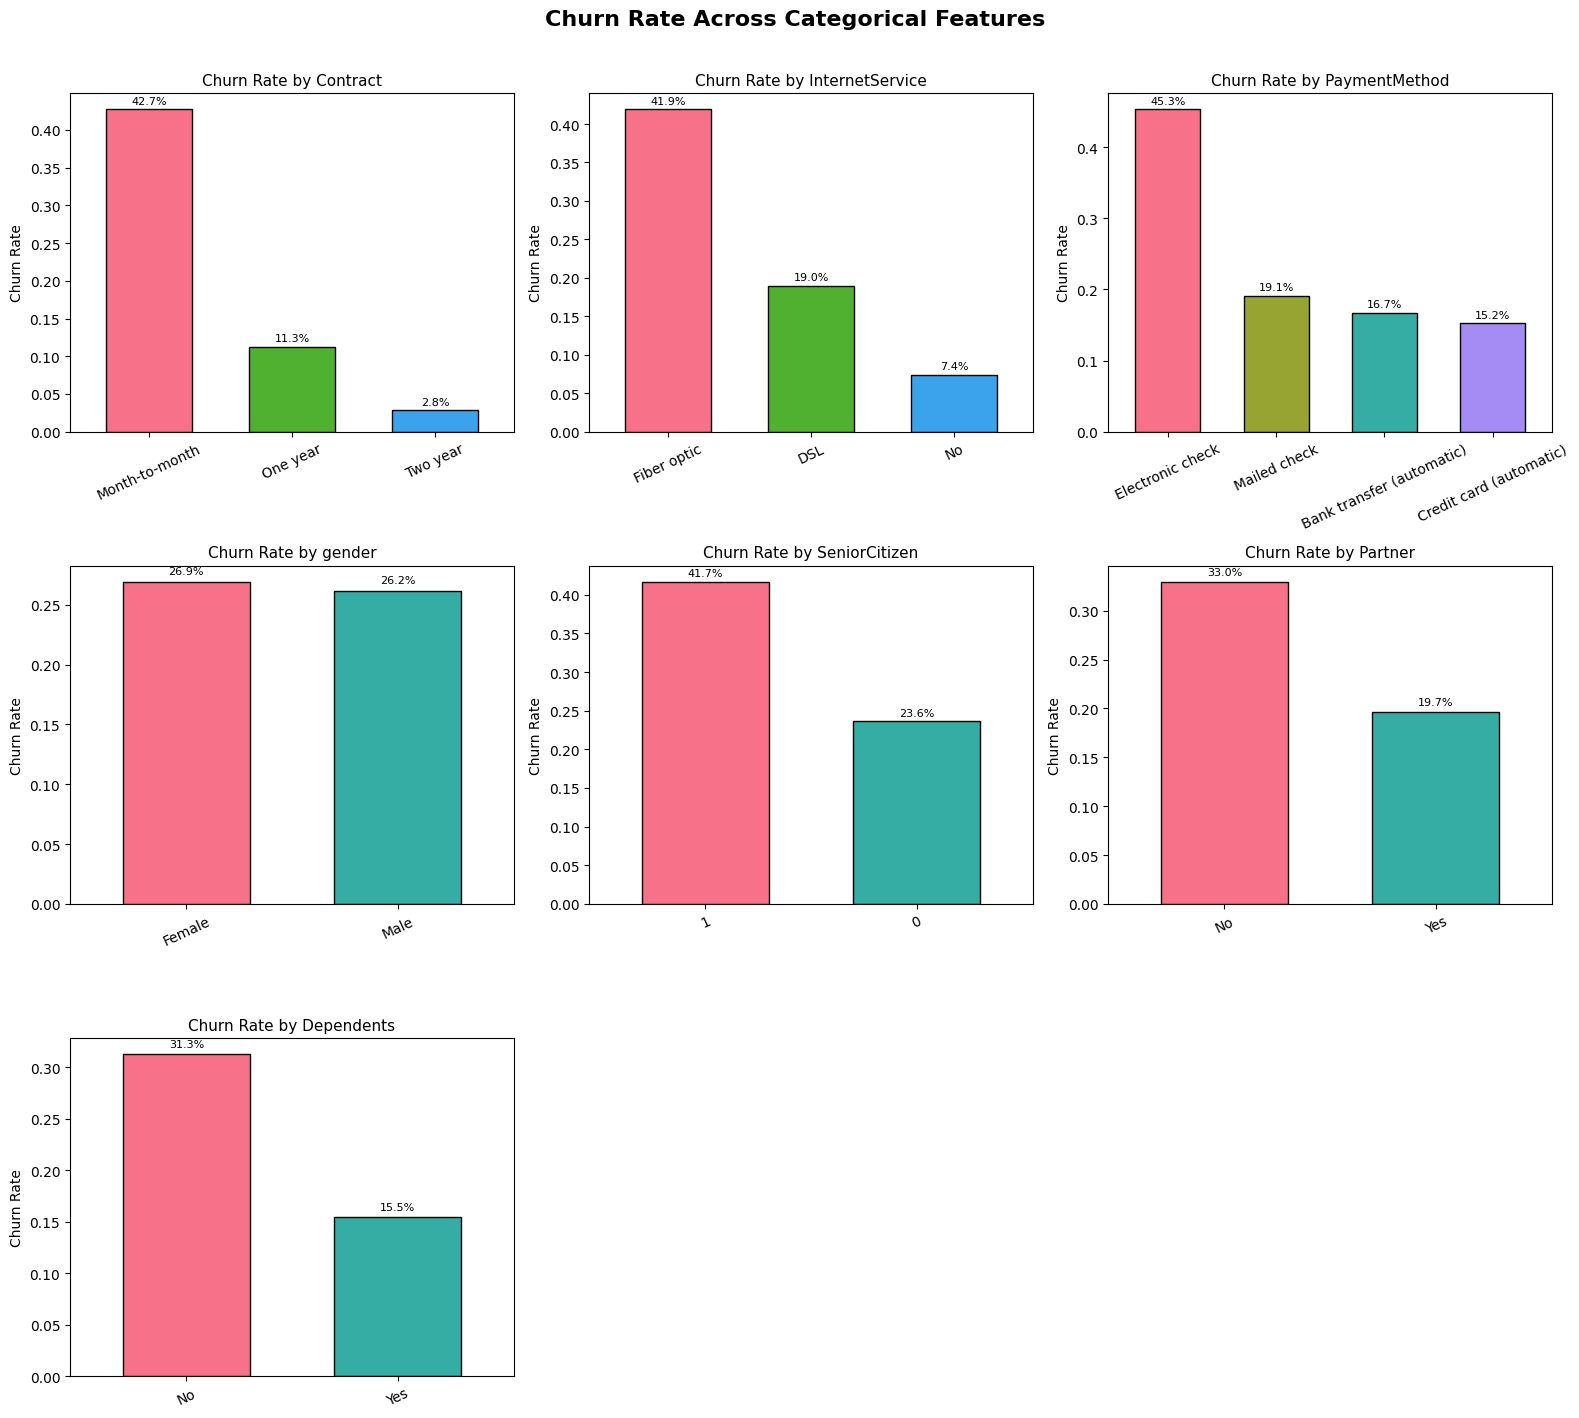

In [36]:
cat_cols = ["Contract","InternetService","PaymentMethod","gender","SeniorCitizen","Partner","Dependents"]
fig, axes = plt.subplots(3, 3, figsize=(16,14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    ct.plot(kind="bar", ax=axes[i], color=sns.color_palette("husl", len(ct)),
            edgecolor="black", width=0.6)
    axes[i].set_title(f"Churn Rate by {col}", fontsize=11)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=8)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Churn Rate Across Categorical Features", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_categorical.png")
plt.show()

### Few insights that the business can use to address the problem

Following features have higher churn rate: month-to-month, fiber optic, electric check payment method, senior citizen, customers with no partners and dependents. The companies can use the information to find out why the reasons for higher churn rate and what actions can they take to address this issue.


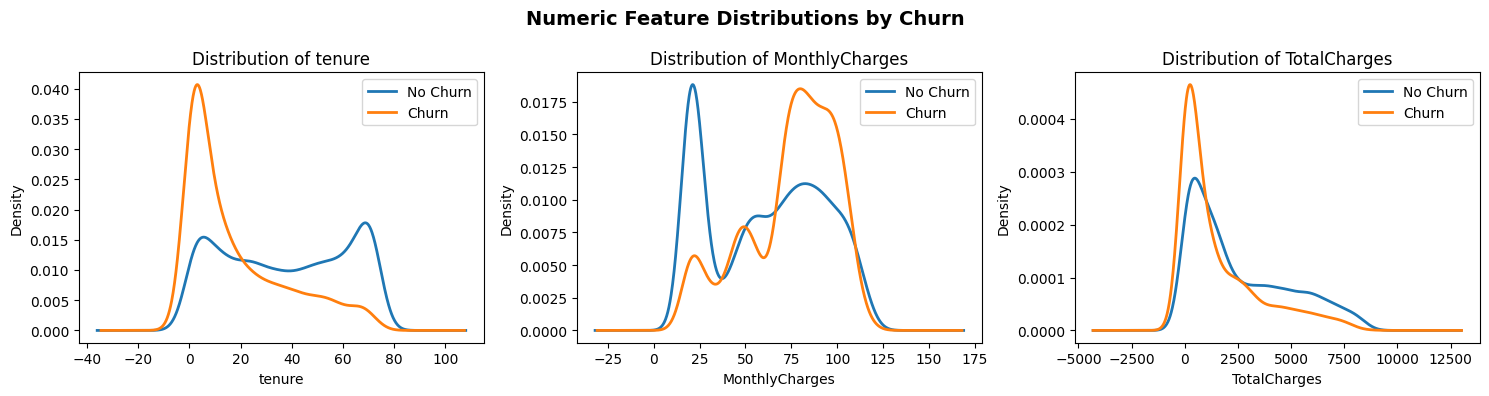

In [37]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("Churn"):
        grp[col].plot.kde(ax=ax, label=["No Churn","Churn"][label], linewidth=2)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle("Numeric Feature Distributions by Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_numeric_dist.png")
plt.show()

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Feature Engineering</span> 
  </h1>
</div>

In [38]:
df_model = df.copy()

# Binary yes/no cols
binary_cols = [c for c in df_model.select_dtypes("object").columns
               if set(df_model[c].unique()) <= {"Yes","No"}]
for c in binary_cols:
    df_model[c] = (df_model[c] == "Yes").astype(int)

# One-hot encode remaining categoricals
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Features after encoding: {df_model.shape[1]-1}")
df_model.head(4)

Features after encoding: 30


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False


In [42]:
X = df_model.copy()
y = X.pop('Churn')

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=32, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s  = scaler.transform(X_valid)
print(f"Train: {len(X_train)} | Test: {len(X_valid)}")

Train: 4930 | Test: 2113


In [45]:
from sklearn.metrics import classification_report
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),  # 50 instead of 200
    "XGBoost":   XGBClassifier(n_estimators=100, learning_rate=0.03, random_state=42),

}
results = {}
for name, model in models.items():
    Xtr, Xte = (X_train_s, X_valid_s) if "Logistic" in name else (X_train, X_valid)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    auc   = roc_auc_score(y_valid, proba)
    results[name] = {"model":model, "preds":preds, "proba":proba, "auc":auc}
    print(f"\n=== {name} (AUC={auc:.4f}) ===")
    print(classification_report(y_valid, preds, target_names=["No Churn","Churn"]))


=== Logistic Regression (AUC=0.8372) ===
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1552
       Churn       0.51      0.78      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.80      0.74      0.76      2113


=== Random Forest (AUC=0.8217) ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1552
       Churn       0.64      0.48      0.55       561

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113


=== XGBoost (AUC=0.8444) ===
              precision    recall  f1-score   support

    No Churn       0.84      0.92      0.88      1552
       Churn       0.69      0.50      0.58       561

    accuracy                           0.81      2113
   macro avg       0